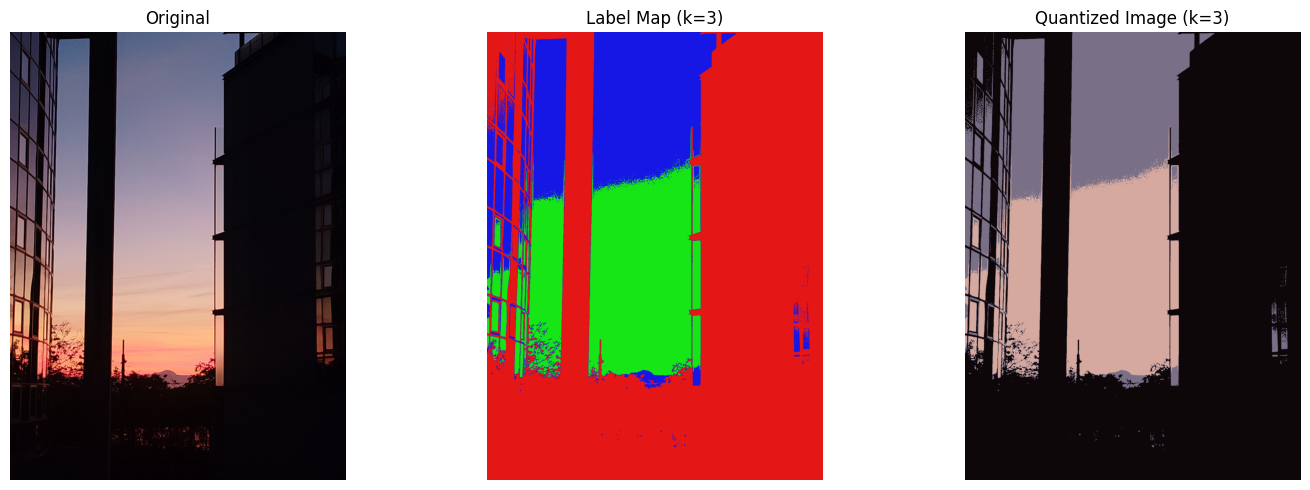

In [14]:
# Image clustering and visualization (Notebook version)

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# --- Configuration ---
image_path = "sun-raise.jpeg"   # Change if needed
k = 3                           # Number of clusters

# --- Load and prepare image ---
img = Image.open(image_path).convert("RGB")
img_arr = np.asarray(img, dtype=np.float32) / 255.0
h, w = img_arr.shape[:2]
pixels = img_arr.reshape(-1, 3)

# --- Run KMeans ---
kmeans = KMeans(n_clusters=k, n_init="auto", random_state=42)
labels = kmeans.fit_predict(pixels)
centers = kmeans.cluster_centers_

# --- Generate label map colors (distinct) ---
def hsv_to_rgb(h, s=0.9, v=0.9):
    i = int(h * 6)
    f = h * 6 - i
    p = v * (1 - s)
    q = v * (1 - f * s)
    t = v * (1 - (1 - f) * s)
    i = i % 6
    if i == 0: r, g, b = v, t, p
    elif i == 1: r, g, b = q, v, p
    elif i == 2: r, g, b = p, v, t
    elif i == 3: r, g, b = p, q, v
    elif i == 4: r, g, b = t, p, v
    else: r, g, b = v, p, q
    return np.array([r, g, b], dtype=np.float32)

palette = np.stack([hsv_to_rgb(h) for h in np.linspace(0, 1, k, endpoint=False)], axis=0)
label_colors = palette[labels].reshape(h, w, 3)

# --- Generate quantized image (using cluster centers) ---
quantized = centers[labels].reshape(h, w, 3)

# --- Display results ---
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(img_arr)
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(label_colors)
axs[1].set_title(f"Label Map (k={k})")
axs[1].axis("off")

axs[2].imshow(quantized)
axs[2].set_title(f"Quantized Image (k={k})")
axs[2].axis("off")

plt.tight_layout()
plt.show()


Using 50,000 sampled pixels.
Running KMeans for k=2...
Running KMeans for k=3...
Running KMeans for k=4...
Running KMeans for k=5...
Running KMeans for k=6...
Running KMeans for k=7...
Running KMeans for k=8...
Running KMeans for k=9...
Running KMeans for k=10...
Running KMeans for k=11...
Running KMeans for k=12...

Best k by silhouette score = 2
Silhouette scores: [0.8153, 0.7703, 0.7551, 0.729, 0.7256, 0.7025, 0.6997, 0.6885, 0.6712, 0.6675, 0.6578]


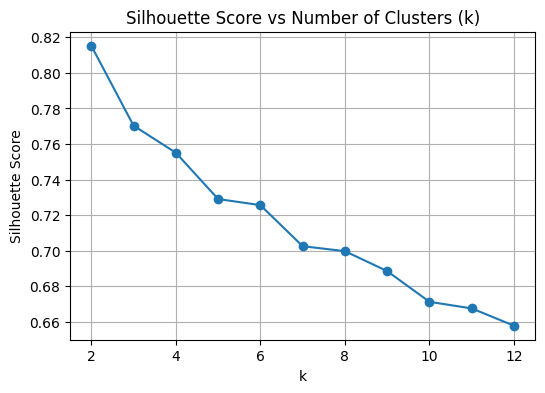

In [12]:
# --- Find best k using Silhouette score only ---

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# -------------------
# Config
# -------------------
image_path = "sun-raise.jpeg"
k_range = range(2, 13)           # try k = 2..12
sample_size = 50000              # sample pixels for faster testing
random_state = 42

# -------------------
# Load and sample pixels
# -------------------
img = Image.open(image_path).convert("RGB")
arr = np.asarray(img, dtype=np.float32) / 255.0
H, W = arr.shape[:2]
pixels = arr.reshape(-1, 3)

N = pixels.shape[0]
if sample_size < N:
    rng = np.random.default_rng(random_state)
    idx = rng.choice(N, size=sample_size, replace=False)
    X = pixels[idx]
else:
    X = pixels

print(f"Using {X.shape[0]:,} sampled pixels.")

# -------------------
# Evaluate silhouette across k
# -------------------
sil_scores = []
for k in k_range:
    print(f"Running KMeans for k={k}...")
    km = KMeans(n_clusters=k, n_init="auto", random_state=random_state)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels, metric="euclidean")
    sil_scores.append(sil)

# -------------------
# Determine best k
# -------------------
best_k = k_range[int(np.argmax(sil_scores))]
print(f"\nBest k by silhouette score = {best_k}")
print("Silhouette scores:", [round(s, 4) for s in sil_scores])

# -------------------
# Plot results
# -------------------
plt.figure(figsize=(6, 4))
plt.plot(list(k_range), sil_scores, marker="o")
plt.title("Silhouette Score vs Number of Clusters (k)")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()
